✅ 图表已保存:
 - charts/novakv_ab_test_20260317_174300.png
 - charts/novakv_ab_test_20260317_174300.pdf


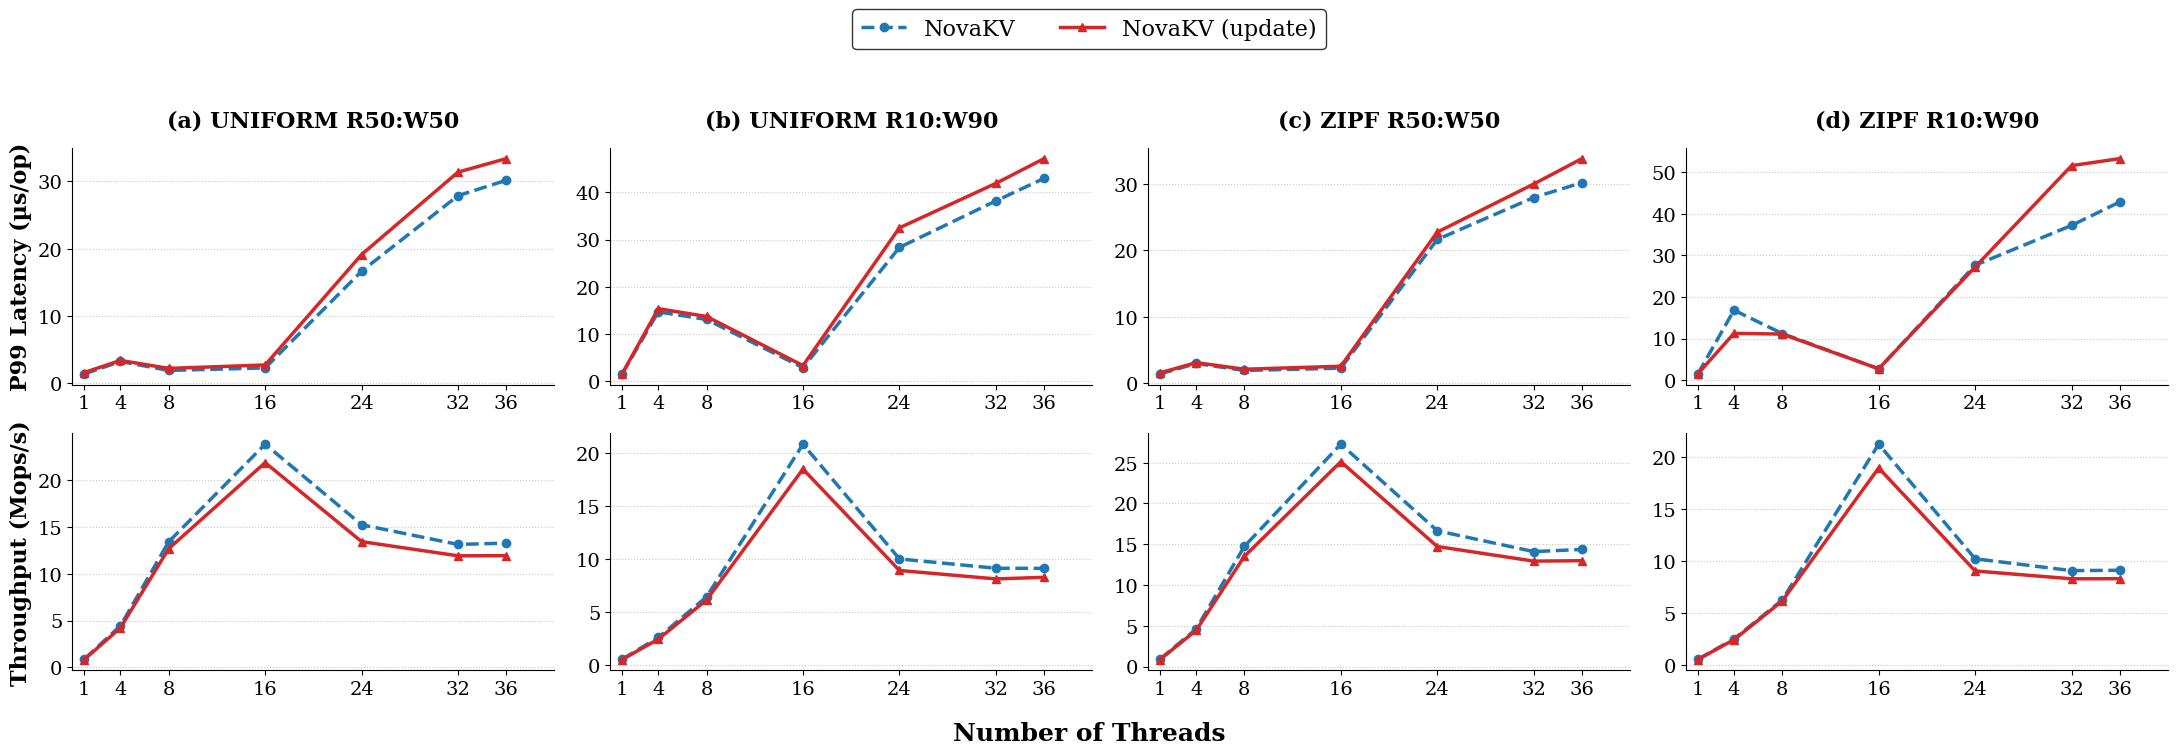

In [2]:
import json
import matplotlib.pyplot as plt
from collections import defaultdict
import re
import os
import datetime

# 1. 配置路径与全局样式
# ========================================================
# ！！！请把这里换成你跑出来的两份真实 JSON 文件路径！！！

RESULT_JSON_NOVAKV_V1 = "/root/NovaKV/results/ycsb/ycsb_2026-03-14-16-16.json" 

RESULT_JSON_NOVAKV_V2 = "/root/NovaKV/results/ycsb/ycsb_2026-03-17-17-33.json" 
# ========================================================

SAVE_DIR = "charts"
os.makedirs(SAVE_DIR, exist_ok=True) 
plt.rcParams['font.size'] = 14
plt.rcParams['font.family'] = 'serif'

# 系统定义：改为对比两个版本的 NovaKV
SYSTEMS = [
    {"file": RESULT_JSON_NOVAKV_V1, "label": "NovaKV", "color": "#1f77b4", "marker": "o", "ls": "--"},
    {"file": RESULT_JSON_NOVAKV_V2, "label": "NovaKV (update)",  "color": "#d62728", "marker": "^", "ls": "-"}
]

FIXTURE_PREFIX = "ViperFixture"
BM_TYPES = ['5050_uniform', '1090_uniform', '5050_zipf', '1090_zipf']

# 2. 读取并解析 JSON 的辅助函数
def load_data(filepath, label):
    runs_dict = defaultdict(list)
    try:
        with open(filepath, 'r') as f:
            results_raw = json.load(f)
        benchmarks = results_raw.get("benchmarks", [])
    except FileNotFoundError:
        print(f"⚠️ 找不到文件: {filepath}")
        return runs_dict

    for run in benchmarks:
        name = run['name']
        found_bm = next((bm for bm in BM_TYPES if bm in name), None)
        
        if found_bm and FIXTURE_PREFIX in name:
            thread_match = re.search(r'threads:(\d+)', name)
            run['threads'] = int(thread_match.group(1)) if thread_match else 1
            runs_dict[(label, found_bm)].append(run)
            
    # 排序确保折线顺滑
    for key in runs_dict:
        runs_dict[key].sort(key=lambda x: x['threads'])
        
    return runs_dict

# 合并两份数据
ALL_RUNS = {}
for sys in SYSTEMS:
    data = load_data(sys["file"], sys["label"])
    ALL_RUNS.update(data)

# 3. 初始化画布 (2行4列)
fig, axes = plt.subplots(2, 4, figsize=(22, 7))
lat_axes = axes[0]
tp_axes = axes[1]
titles = ["(a) UNIFORM R50:W50", "(b) UNIFORM R10:W90", "(c) ZIPF R50:W50", "(d) ZIPF R10:W90"]

# 4. 绘图循环
for col, bm_type in enumerate(BM_TYPES):
    lt_ax, tp_ax = lat_axes[col], tp_axes[col]
    
    for sys in SYSTEMS:
        label = sys["label"]
        data_list = ALL_RUNS.get((label, bm_type), [])
        
        if not data_list:
            continue
            
        tp_data = [r for r in data_list if "_tp" in r['name']]
        lat_data = [r for r in data_list if "_lat" in r['name']]
        
        if tp_data:
            x = [r['threads'] for r in tp_data]
            y = [r['items_per_second'] / 1_000_000 for r in tp_data]
            tp_ax.plot(x, y, marker=sys["marker"], color=sys["color"], 
                       lw=2.5, ls=sys["ls"], label=label)
            
        if lat_data:
            x = [r['threads'] for r in lat_data]
            # ⭐️ 核心修改：改为提取 P99 尾延迟 (hdr_99)，最能体现压实优化的效果！
            y = [r.get('hdr_99', r.get('hdr_avg')) / 1000 for r in lat_data] 
            lt_ax.plot(x, y, marker=sys["marker"], color=sys["color"], 
                       lw=2.5, ls=sys["ls"])

    # 5. 子图细节规范化
    for ax in [lt_ax, tp_ax]:
        ax.set_xticks([1, 4, 8, 16, 24, 32, 36]) 
        ax.set_xlim(0, 40) 
        ax.grid(axis='y', linestyle=':', alpha=0.7)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    lt_ax.set_title(titles[col], fontsize=16, fontweight='bold', pad=15)
    
    # 因为两个版本性能都很高，去掉之前限制上限的代码，让它自适应展示两者的微小差距
    # tp_ax.set_ylim(0, 30) 

# 6. 全局修饰
lat_axes[0].set_ylabel("P99 Latency (µs/op)", fontsize=16, fontweight='bold')
tp_axes[0].set_ylabel("Throughput (Mops/s)", fontsize=16, fontweight='bold')
fig.text(0.5, 0.02, "Number of Threads", ha='center', fontsize=18, fontweight='bold')

# 提取并设置图例
handles, labels = tp_axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), 
               ncol=2, frameon=True, edgecolor='black', fontsize=16)

# 7. 调整布局并保存
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
png_path = os.path.join(SAVE_DIR, f'novakv_ab_test_{timestamp}.png')
pdf_path = os.path.join(SAVE_DIR, f'novakv_ab_test_{timestamp}.pdf')

plt.savefig(png_path, bbox_inches='tight', dpi=300)
plt.savefig(pdf_path, bbox_inches='tight', dpi=300)

print(f"✅ 图表已保存:\n - {png_path}\n - {pdf_path}")